Predictions:
[0 0 1 1 1 0 1 0 1 1 1 1 1 0]
Accuracy: 1.0


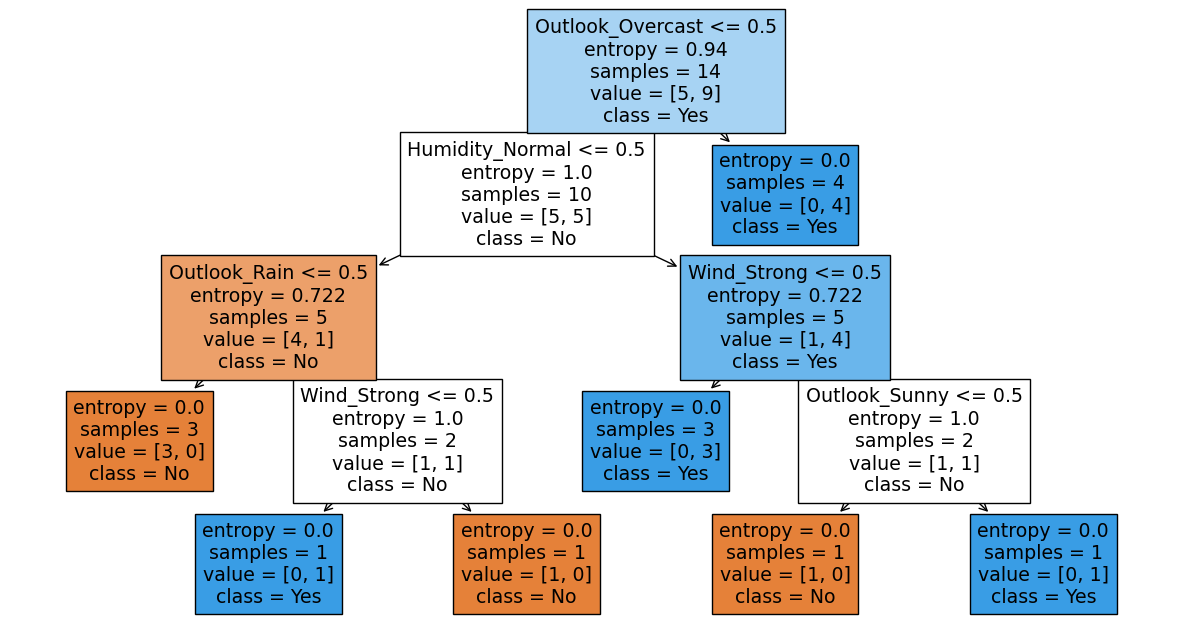

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain',
                'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain',
                'Sunny', 'Overcast', 'Overcast', 'Rain'],
    
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool',
                    'Cool', 'Cool', 'Mild', 'Cool', 'Mild',
                    'Mild', 'Mild', 'Hot', 'Mild'],
    
    'Humidity': ['High', 'High', 'High', 'High', 'Normal',
                 'Normal', 'Normal', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'High'],
    
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak',
             'Strong', 'Strong', 'Weak', 'Weak', 'Weak',
             'Strong', 'Strong', 'Weak', 'Strong'],
    
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes',
             'No', 'Yes', 'No', 'Yes', 'Yes',
             'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

# Convert categorical values into numbers
df_encoded = pd.get_dummies(df, columns=['Outlook', 'Temperature',
                                          'Humidity', 'Wind'])

# Separate input and output
X = df_encoded.drop('Play', axis=1)
y = df_encoded['Play'].map({'No': 0, 'Yes': 1})

# Create ID3 Decision Tree
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

# Train the model
model.fit(X, y)

# Prediction
prediction = model.predict(X)

print("Predictions:")
print(prediction)

# Accuracy
accuracy = model.score(X, y)
print("Accuracy:", accuracy)

# Display tree
plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()